import libraries

In [1]:
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.models import Sequential
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings("ignore")

load data

In [2]:
tsla = pd.read_csv(
    "../data/processed/TSLA.csv",
    index_col=0,
    parse_dates=True
)

tsla = tsla[["Close"]]

tsla.head()

,Close
Date,
2015-01-02,14.620667
2015-01-05,14.006000
2015-01-06,14.085333
2015-01-07,14.063333
2015-01-08,14.041333


scaling

In [3]:
scaler = MinMaxScaler(feature_range=(0, 1))

scaled_data = scaler.fit_transform(tsla)

creating sequences

In [4]:
window_size = 60

X = []
y = []

for i in range(window_size, len(scaled_data)):
    X.append(scaled_data[i-window_size:i, 0])
    y.append(scaled_data[i, 0])

X = np.array(X)
y = np.array(y)

X = X.reshape(X.shape[0], X.shape[1], 1)

print(X.shape)

(2828, 60, 1)


train/test split

In [5]:
split_index = tsla.index.get_loc("2025-01-02")

train_size = split_index

X_train = X[:train_size-window_size]
y_train = y[:train_size-window_size]

X_test = X[train_size-window_size:]
y_test = y[train_size-window_size:]

print(X_train.shape)
print(X_test.shape)

(2456, 60, 1)
(372, 60, 1)


buil LSTM

In [6]:
model = Sequential()

model.add(
    LSTM(
        units=50,
        input_shape=(window_size, 1)
    )
)

model.add(Dense(1))

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 50)             │        10,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,451 (40.82 KB)

 Trainable params: 10,451 (40.82 KB)

 Non-trainable params: 0 (0.00 B)

train the model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=20,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0080 - val_loss: 0.0025
Epoch 2/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 7.7107e-04 - val_loss: 0.0020
Epoch 3/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 7.0195e-04 - val_loss: 0.0019
Epoch 4/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 6.3022e-04 - val_loss: 0.0019
Epoch 5/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - loss: 5.7023e-04 - val_loss: 0.0018
Epoch 6/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 3s 34ms/step - loss: 5.4022e-04 - val_loss: 0.0015
Epoch 7/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.9374e-04 - val_loss: 0.0021
Epoch 8/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - loss: 4.7634e-04 - val_loss: 0.0017
Epoch 9/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - loss: 4.6890e-04 - val_loss: 0.0020
Epoch 10/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - loss: 4.2375e-04 - val_loss: 0.0013
Epoch 11/20
77/77 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - loss: 4.0600e-04 - val_loss: 0.0019
Epoch 12/20
77/77 ━━━━━

predict test data

In [8]:
predictions = model.predict(X_test)

predictions = scaler.inverse_transform(predictions)

actual = scaler.inverse_transform(
    y_test.reshape(-1, 1)
)

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step


plot test prediction 

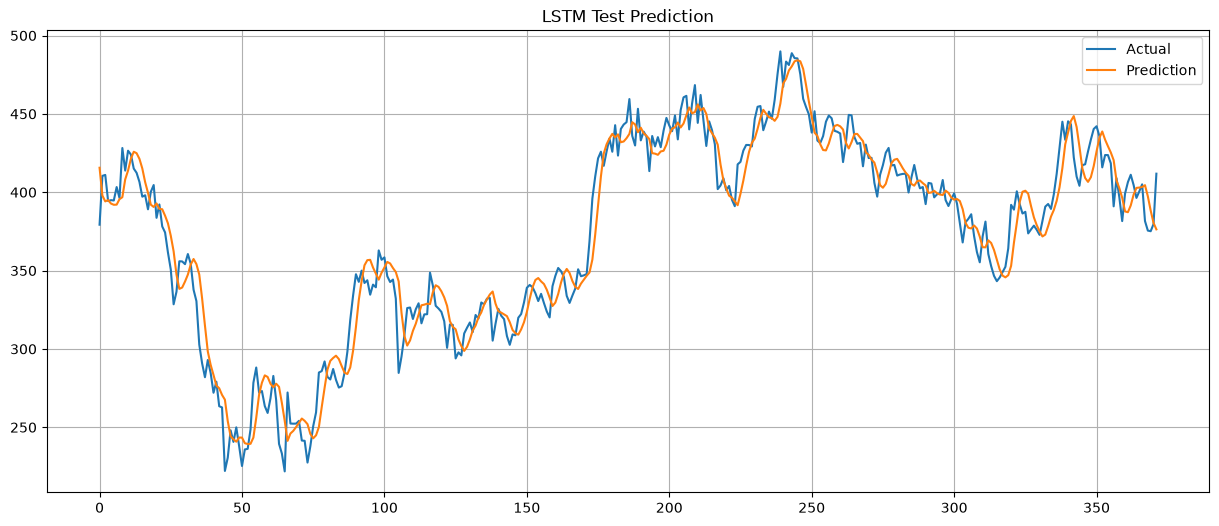

In [9]:
plt.figure(figsize=(15, 6))

plt.plot(actual, label="Actual")

plt.plot(predictions, label="Prediction")

plt.title("LSTM Test Prediction")

plt.legend()

plt.grid(True)

plt.show()

forecast next 6 month

In [10]:
future_steps = 126

last_sequence = scaled_data[-window_size:]

last_sequence = last_sequence.reshape(
    1,
    window_size,
    1
)

future_predictions = []

for _ in range(future_steps):

    pred = model.predict(
        last_sequence,
        verbose=0
    )

    future_predictions.append(pred[0, 0])

    last_sequence = np.append(
        last_sequence[:, 1:, :],
        pred.reshape(1, 1, 1),
        axis=1
    )

convert back to prices

In [11]:
future_predictions = scaler.inverse_transform(
    np.array(future_predictions).reshape(-1, 1)
)

create feature dates

In [12]:
future_dates = pd.bdate_range(
    start=tsla.index[-1] + pd.Timedelta(days=1),
    periods=future_steps
)

plot feature forecast

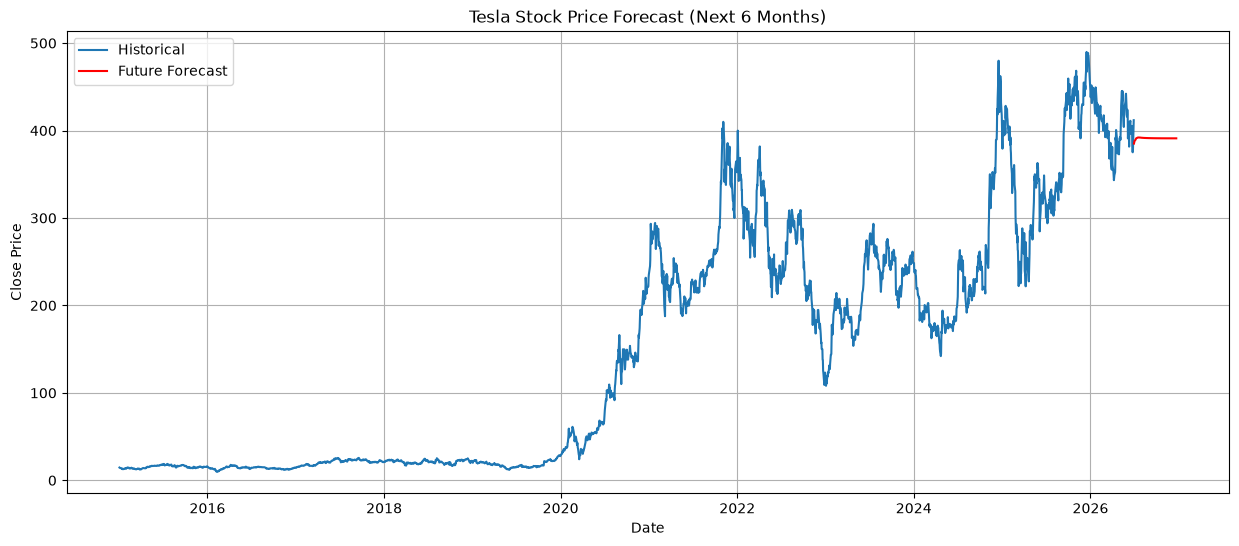

In [13]:
plt.figure(figsize=(15, 6))

plt.plot(
    tsla.index,
    tsla["Close"],
    label="Historical"
)

plt.plot(
    future_dates,
    future_predictions,
    color="red",
    label="Future Forecast"
)

plt.title("Tesla Stock Price Forecast (Next 6 Months)")

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.legend()

plt.grid(True)

plt.show()

show forecast table

In [14]:
forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast Price": future_predictions.flatten()
})

forecast_df.head(10)

,Date,Forecast Price
0,2026-06-30,385.107086
1,2026-07-01,386.404236
2,2026-07-02,387.486023
3,2026-07-03,388.431549
4,2026-07-06,389.239014
5,2026-07-07,389.917084
6,2026-07-08,390.475586
7,2026-07-09,390.925537
8,2026-07-10,391.278473
9,2026-07-13,391.547119


 Trend Analysis

The LSTM forecast indicates a relatively stable Tesla stock price over the next six months with a slight upward trend. The model predicts that prices will remain close to the recent trading range, suggesting no significant acceleration or decline during the forecast horizon. This may indicate a period of market consolidation following the higher volatility observed in previous years.